In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [2]:
observations = 1000000
xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(low=-10, high=10, size=(observations,1))
inputs = np.column_stack((xs,zs))
print(inputs.shape)

(1000000, 2)


In [3]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13*xs + 7*zs - 12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000000, 1)


In [27]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

OverflowError: Exceeded cell block limit in Agg.  Please set the value of rcParams['agg.path.chunksize'], (currently 0) to be greater than 100 or increase the path simplification threshold(rcParams['path.simplify_threshold'] = 0.111111111111 by default and path.simplify_threshold = 0.111111111111 on the input).

<Figure size 640x480 with 1 Axes>

In [28]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[0.03919356]
 [0.00889423]] [0.01336491]


In [29]:
targets = targets.reshape(observations, 1)
eta = 1

for i in range(100):
    outputs = np.dot(inputs, weights) + biases
    deltas = outputs - targets

    loss = np.sum(deltas ** 2) / 2 / observations
    print(loss)

    deltas_scaled = deltas / observations
    weights = weights - eta * np.dot(inputs.T, deltas_scaled)
    biases = biases - eta * np.sum(deltas_scaled)

227.5951276144876
224990.00625910953
235454437.9775376
246406318548.80493
257868195582139.34
2.6986384229721635e+17
2.8241814129100492e+20
2.9555713616787325e+23
3.093080857556767e+26
3.2369952085564774e+29
3.387613036443202e+32
3.545246898516484e+35
3.710223938450178e+38
3.882886567550941e+41
4.0635931778581055e+44
4.252718888573112e+47
4.4506563273785676e+50
4.657816448277252e+53
4.87462938766045e+56
5.10154536039342e+59
5.339035597788701e+62
5.587593329428367e+65
5.847734810884965e+68
6.120000399487739e+71
6.404955680384456e+74
6.703192645248007e+77
7.015330926092463e+80
7.342019086777049e+83
7.683935974894914e+86
8.041792136875512e+89
8.416331299252541e+92
8.808331919198914e+95
9.218608807565483e+98
9.648014827816446e+101
1.0097442674415998e+105
1.0567826734378908e+108
1.1060145035879086e+111
1.1575421287990603e+114
1.2114727015822295e+117
1.2679183795515486e+120
1.3269965593770901e+123
1.3888301216801885e+126
1.4535476873833812e+129
1.5212838860509246e+132
1.5921796367809e+135
1.6

In [10]:
print(weights, biases)

[[ 2.00013687]
 [-3.00246566]] [4.33126003]


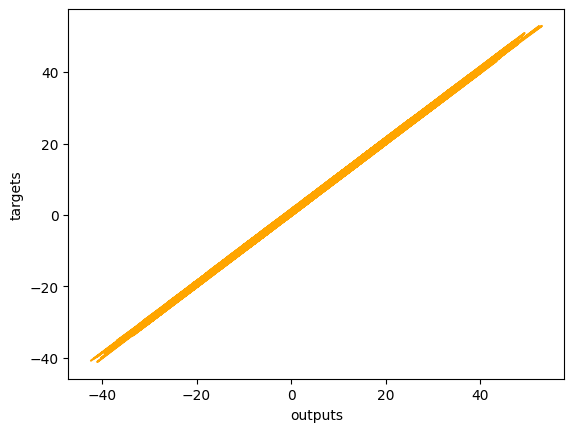

In [11]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()